### Model Lead


In [14]:
# Import library
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Wrapper kompatibilitas: NumPy 1.x pakai np.trapz, NumPy 2.x pakai np.trapezoid
_trapz = getattr(np, 'trapezoid', None) or np.trapz

# Parameter model (dapat diubah)
T1 = 10.0   # akhir fase 1 (akselerasi)
T2 = 60.0   # akhir fase 2 (konstan)
T3 = 80.0   # akhir fase 3 (deselerasi) = T total
V_MAX = 20.0  # kecepatan jelajah (m/s)

print("Parameter model:")
print(f"  Fase 1 (akselerasi)  : 0  <= t <= {T1:.0f}  s,  v(t) = 2t")
print(f"  Fase 2 (konstan)     : {T1:.0f} <  t <= {T2:.0f}  s,  v(t) = {V_MAX:.0f}")
print(f"  Fase 3 (deselerasi)  : {T2:.0f} <  t <= {T3:.0f}  s,  v(t) = 80 - t")


Parameter model:
  Fase 1 (akselerasi)  : 0  <= t <= 10  s,  v(t) = 2t
  Fase 2 (konstan)     : 10 <  t <= 60  s,  v(t) = 20
  Fase 3 (deselerasi)  : 60 <  t <= 80  s,  v(t) = 80 - t


### Symbolic Lead

In [15]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.Symbol('t', real=True, nonnegative=True)

# Definisi fungsi kecepatan v(t)
v_sym = sp.Piecewise(
    (2*t,    t <= 10),   # fase percepatan
    (20,     t <= 60),   # kecepatan konstan
    (80 - t, t <= 80)    # fase perlambatan
)

print("v(t) =")
sp.pprint(v_sym)

v(t) =
⎧ 2⋅t    for t ≤ 10
⎪                  
⎨  20    for t ≤ 60
⎪                  
⎩80 - t  for t ≤ 80


In [16]:
# hitung jarak tiap fase
s1_sym = sp.integrate(2*t,    (t, 0,  10))
s2_sym = sp.integrate(20,     (t, 10, 60))
s3_sym = sp.integrate(80 - t, (t, 60, 80))

s_total_sym = s1_sym + s2_sym + s3_sym

print(f"s1 (akselerasi)  = {s1_sym} m")
print(f"s2 (konstan)     = {s2_sym} m")
print(f"s3 (deselerasi)  = {s3_sym} m")
print(f"Total            = {s_total_sym} m")

s1 (akselerasi)  = 100 m
s2 (konstan)     = 1000 m
s3 (deselerasi)  = 200 m
Total            = 1300 m


In [17]:
# cek ulang pakai integral langsung
s_check = sp.integrate(v_sym, (t, 0, 80))
print(f"Integral langsung: {sp.simplify(s_check)} m")
print(f"Sama dengan sebelumnya? {sp.simplify(s_check - s_total_sym) == 0}")

Integral langsung: 1300 m
Sama dengan sebelumnya? True


In [18]:
# Simpan nilai analitik sebagai float untuk dipakai di Bagian D & E
S1_ANALYTIC = float(s1_sym)
S2_ANALYTIC = float(s2_sym)
S3_ANALYTIC = float(s3_sym)
S_TOTAL_ANALYTIC = float(s_total_sym)

print(f"S1_ANALYTIC      = {S1_ANALYTIC} m")
print(f"S2_ANALYTIC      = {S2_ANALYTIC} m")
print(f"S3_ANALYTIC      = {S3_ANALYTIC} m")
print(f"S_TOTAL_ANALYTIC = {S_TOTAL_ANALYTIC} m  (= {S_TOTAL_ANALYTIC/1000:.2f} km)")

S1_ANALYTIC      = 100.0 m
S2_ANALYTIC      = 1000.0 m
S3_ANALYTIC      = 200.0 m
S_TOTAL_ANALYTIC = 1300.0 m  (= 1.30 km)


### Numeric Lead

In [19]:
# implementasi v(t) numerik
def v_num(t_array):
    t_array = np.asarray(t_array, dtype=float)
    return np.piecewise(
        t_array,
        [
            t_array <= 10,
            (t_array > 10) & (t_array <= 60),
            t_array > 60
        ],
        [
            lambda x: 2 * x,
            lambda x: 20.0,
            lambda x: 80 - x
        ]
    )

# sanity check di titik-titik penting
print("Cek nilai v(t) di titik kunci:")
for t_test in [0, 5, 10, 35, 60, 70, 80]:
    print(f"  v({t_test:>2}) = {v_num(t_test):.1f} m/s")

Cek nilai v(t) di titik kunci:
  v( 0) = 0.0 m/s
  v( 5) = 10.0 m/s
  v(10) = 20.0 m/s
  v(35) = 20.0 m/s
  v(60) = 20.0 m/s
  v(70) = 10.0 m/s
  v(80) = 0.0 m/s


In [20]:
# kompatibilitas NumPy 1.x vs 2.x
_trapz = getattr(np, 'trapezoid', None) or np.trapz

# fungsi integral trapesium untuk satu fase
def trapz_phase(t_start, t_end, n):
    tt = np.linspace(t_start, t_end, n + 1)
    vv = v_num(tt)
    return _trapz(vv, tt)

# hitung untuk dua resolusi
for n in [1_000, 100_000]:
    s1_n = trapz_phase(0,  10, n)
    s2_n = trapz_phase(10, 60, n)
    s3_n = trapz_phase(60, 80, n)
    s_tot = s1_n + s2_n + s3_n

    print(f"n = {n:,} titik per fase:")
    print(f"  s1 (akselerasi)  = {s1_n:.8f} m")
    print(f"  s2 (konstan)     = {s2_n:.8f} m")
    print(f"  s3 (deselerasi)  = {s3_n:.8f} m")
    print(f"  total            = {s_tot:.8f} m")
    print()

n = 1,000 titik per fase:
  s1 (akselerasi)  = 100.00000000 m
  s2 (konstan)     = 1000.00000000 m
  s3 (deselerasi)  = 200.00000000 m
  total            = 1300.00000000 m

n = 100,000 titik per fase:
  s1 (akselerasi)  = 100.00000000 m
  s2 (konstan)     = 1000.00000000 m
  s3 (deselerasi)  = 200.00000000 m
  total            = 1300.00000000 m



### Validasi Hasil

In [21]:
# validasi hasil (selisih absolut dan relatif, serta alasan perbedaan).

# hitung nilai analitik dengan SymPy 
t = sp.Symbol('t', real=True)

S1_ANALYTIC = float(sp.integrate(2*t,        (t, 0,  10)))  # = 100.0 m
S2_ANALYTIC = float(sp.integrate(20,         (t, 10, 60)))  # = 1000.0 m
S3_ANALYTIC = float(sp.integrate(80 - t,     (t, 60, 80)))  # = 200.0 m
S_TOTAL_ANALYTIC = S1_ANALYTIC + S2_ANALYTIC + S3_ANALYTIC  # = 1300.0 m

print("Hasil analitik (SymPy):")
print(f"  Fase 1 : {S1_ANALYTIC} m")
print(f"  Fase 2 : {S2_ANALYTIC} m")
print(f"  Fase 3 : {S3_ANALYTIC} m")
print(f"  Total  : {S_TOTAL_ANALYTIC} m")

# error analisis untuk berbagai nilai n 
n_values = [1_000, 100_000]

print("\n Error Analysis")
for n in n_values:
    s1_n    = trapz_phase(0,  10, n)
    s2_n    = trapz_phase(10, 60, n)
    s3_n    = trapz_phase(60, 80, n)
    s_tot_n = s1_n + s2_n + s3_n

    hasil = [
        ("Fase 1 (akselerasi)",  s1_n,    S1_ANALYTIC),
        ("Fase 2 (konstan)",     s2_n,    S2_ANALYTIC),
        ("Fase 3 (deselerasi)",  s3_n,    S3_ANALYTIC),
        ("Total",               s_tot_n, S_TOTAL_ANALYTIC),
    ]

    print(f"\n n = {n:,} titik")
    for label, s_n, s_a in hasil:
        err_abs = abs(s_n - s_a) # hitung error absolut
        err_rel = err_abs / abs(s_a) if s_a != 0 else 0.0 # hitung error relatif

        print(f"  {label}")
        print(f"    Numerik  : {s_n:.6f} m")
        print(f"    Analitik : {s_a:.6f} m")
        print(f"    Err abs  : {err_abs:.2e} m")
        print(f"    Err rel  : {err_rel:.2e} ")




Hasil analitik (SymPy):
  Fase 1 : 100.0 m
  Fase 2 : 1000.0 m
  Fase 3 : 200.0 m
  Total  : 1300.0 m

 Error Analysis

 n = 1,000 titik
  Fase 1 (akselerasi)
    Numerik  : 100.000000 m
    Analitik : 100.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 
  Fase 2 (konstan)
    Numerik  : 1000.000000 m
    Analitik : 1000.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 
  Fase 3 (deselerasi)
    Numerik  : 200.000000 m
    Analitik : 200.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 
  Total
    Numerik  : 1300.000000 m
    Analitik : 1300.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 

 n = 100,000 titik
  Fase 1 (akselerasi)
    Numerik  : 100.000000 m
    Analitik : 100.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 
  Fase 2 (konstan)
    Numerik  : 1000.000000 m
    Analitik : 1000.000000 m
    Err abs  : 0.00e+00 m
    Err rel  : 0.00e+00 
  Fase 3 (deselerasi)
    Numerik  : 200.000000 m
    Analitik : 200.000000 m
    E

Penjelasan hasil validasi : 
Hasil validasi menunjukkan bahwa nilai integral numerik yang diperoleh menggunakan metode trapesium sangat dekat dengan hasil analitik yang dihitung menggunakan SymPy. Error absolut dan error relatif pada setiap fase bernilai nol atau mendekati nol. Karena fungsi yang digunakan hanya fungsi linear dan konstan. Metode trapesium memberikan hasil eksak untuk fungsi linear, sehingga hasil numerik sama dengan hasil analitik.

### Visualization & Reporting Lead

Visualisasi v(t) per fase (tiga warna berbeda, garis pemisah fase, dan arsiran area yang menunjukkan jarak tempuh tiap fase), serta plot posisi kumulatif s(t) sebagai antiturunan dari v(t).

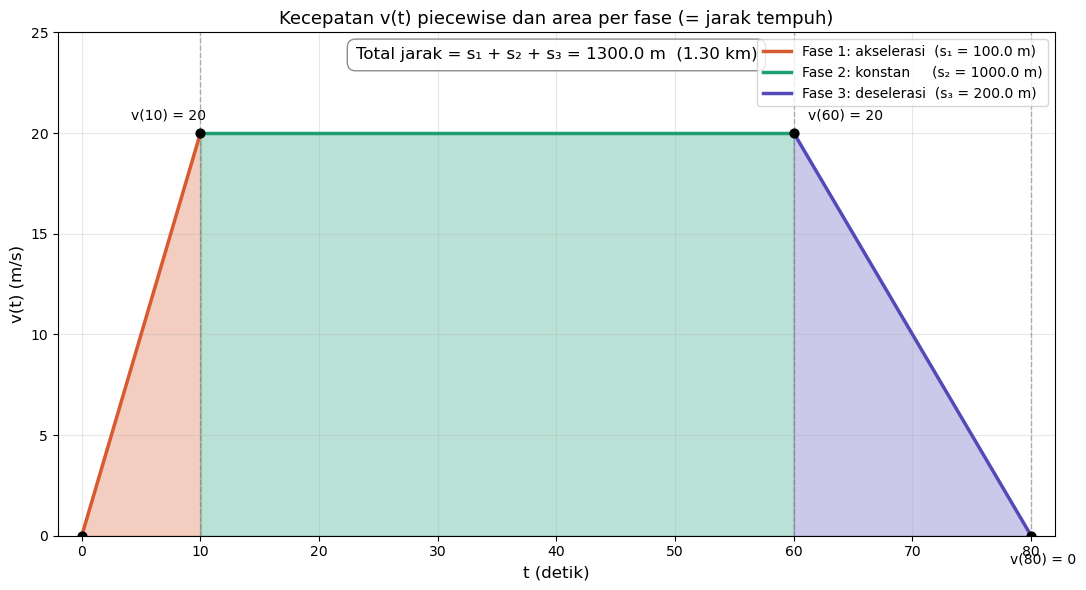

In [22]:
# Plot piecewise dengan penanda fase
def plot_piecewise(n=1000):
    # Sampling per fase agar transisi tajam terlihat bersih
    tt1 = np.linspace(0,  10, n + 1)
    tt2 = np.linspace(10, 60, n + 1)
    tt3 = np.linspace(60, 80, n + 1)
    vv1 = v_num(tt1)
    vv2 = v_num(tt2)
    vv3 = v_num(tt3)

    s1 = _trapz(vv1, tt1)
    s2 = _trapz(vv2, tt2)
    s3 = _trapz(vv3, tt3)

    fig, ax = plt.subplots(figsize=(11, 6))

    # Warna per fase (3 kategori semantik berbeda)
    c1, c2, c3 = '#D85A30', '#1D9E75', '#534AB7'  # coral, teal, purple

    ax.plot(tt1, vv1, color=c1, linewidth=2.5, label=f'Fase 1: akselerasi  (s₁ = {s1:.1f} m)')
    ax.plot(tt2, vv2, color=c2, linewidth=2.5, label=f'Fase 2: konstan     (s₂ = {s2:.1f} m)')
    ax.plot(tt3, vv3, color=c3, linewidth=2.5, label=f'Fase 3: deselerasi  (s₃ = {s3:.1f} m)')

    # Arsir area per fase
    ax.fill_between(tt1, vv1, alpha=0.30, color=c1)
    ax.fill_between(tt2, vv2, alpha=0.30, color=c2)
    ax.fill_between(tt3, vv3, alpha=0.30, color=c3)

    # Garis vertikal pemisah fase
    for t_bound in [10, 60, 80]:
        ax.axvline(x=t_bound, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    # Label sambungan
    ax.scatter([0, 10, 60, 80], [0, 20, 20, 0], color='black', zorder=5, s=40)
    ax.annotate('v(10) = 20',  (10, 20), textcoords='offset points', xytext=(-50, 10), fontsize=10)
    ax.annotate('v(60) = 20',  (60, 20), textcoords='offset points', xytext=(10, 10), fontsize=10)
    ax.annotate('v(80) = 0',   (80, 0),  textcoords='offset points', xytext=(-15, -20), fontsize=10)

    # Total jarak
    s_total = s1 + s2 + s3
    ax.text(0.5, 0.97, f'Total jarak = s₁ + s₂ + s₃ = {s_total:.1f} m  ({s_total/1000:.2f} km)',
            transform=ax.transAxes, ha='center', va='top', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    ax.set_xlabel('t (detik)', fontsize=12)
    ax.set_ylabel('v(t) (m/s)', fontsize=12)
    ax.set_title('Kecepatan v(t) piecewise dan area per fase (= jarak tempuh)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(-2, 82)
    ax.set_ylim(0, 25)

    plt.tight_layout()
    plt.show()

plot_piecewise()

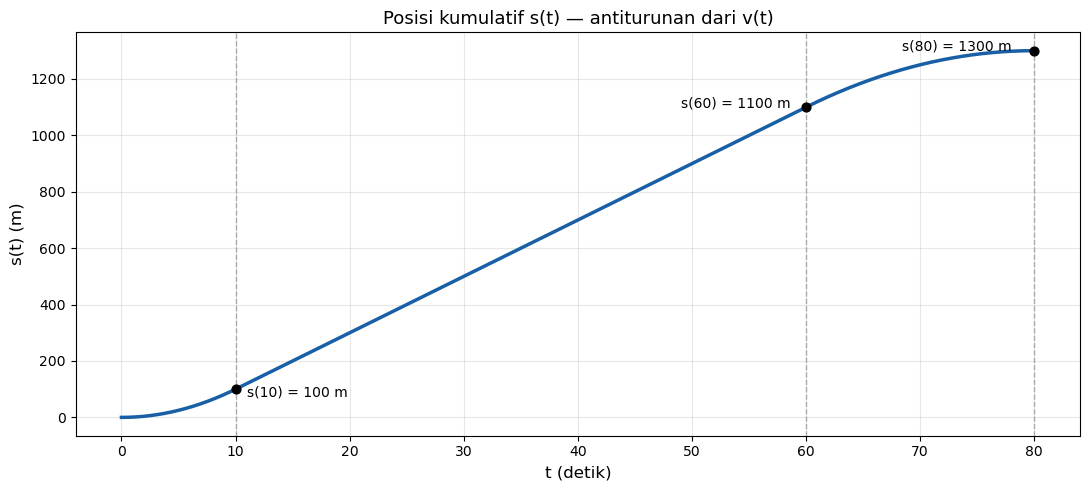

In [23]:
# Plot tambahan: posisi kumulatif s(t) sebagai antiturunan v(t)
def plot_position():
    n = 5000
    tt = np.linspace(0, 80, n + 1)
    vv = v_num(tt)
    # Posisi kumulatif: integrasi numerik bertahap
    ss = np.concatenate(([0], np.cumsum((vv[:-1] + vv[1:]) / 2 * np.diff(tt))))

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(tt, ss, color='#185FA5', linewidth=2.5)
    for t_bound in [10, 60, 80]:
        ax.axvline(x=t_bound, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([10, 60, 80], [ss[tt <= 10][-1], ss[tt <= 60][-1], ss[-1]],
               color='black', zorder=5, s=40)
    ax.annotate(f's(10) = {ss[tt<=10][-1]:.0f} m',  (10, ss[tt<=10][-1]),
                textcoords='offset points', xytext=(8, -5), fontsize=10)
    ax.annotate(f's(60) = {ss[tt<=60][-1]:.0f} m', (60, ss[tt<=60][-1]),
                textcoords='offset points', xytext=(-90, 0), fontsize=10)
    ax.annotate(f's(80) = {ss[-1]:.0f} m', (80, ss[-1]),
                textcoords='offset points', xytext=(-95, 0), fontsize=10)
    ax.set_xlabel('t (detik)', fontsize=12)
    ax.set_ylabel('s(t) (m)', fontsize=12)
    ax.set_title('Posisi kumulatif s(t) — antiturunan dari v(t)', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_position()

Penjelasan hasil visualisasi :
Plot pertama menampilkan kurva kecepatan v(t) yang dibagi menjadi tiga fase dengan warna berbeda. Luas daerah di bawah tiap kurva merepresentasikan jarak tempuh per fase (s₁ = 100 m, s₂ = 1000 m, s₃ = 200 m), dengan total 1300 m (1,3 km). Garis vertikal putus-putus menandai titik sambungan antar fase (t = 10, 60, 80), dan kurva terlihat kontinu tanpa loncatan di titik-titik tersebut. Plot kedua menampilkan posisi kumulatif s(t) sebagai antiturunan dari v(t), yang naik monoton dan mencapai 1300 m di akhir perjalanan.